# <b><u>**Feature Selection Analysis on Student Exam Performance Dataset**<b><u>
This notebook applies 9 feature selection techniques to identify 
the most important variables that influence student exam scores. 

RFECV is used first to scientifically determine the optimal number 
of features, which is then validated across all methods.

### <b><u>**Introduction**<b><u>

Feature selection is a critical step in machine learning that:
- Removes irrelevant and redundant features
- Reduces overfitting
- Improves model performance
- Decreases computational cost

### <b><u>**Approach Used in This Notebook:**<b><u>
1. **Baseline model** built with all 23 features to establish R² benchmark
2. **RFECV** used to scientifically find the optimal number of features
3. **9 Feature Selection Methods** applied and validated
4. **Final model** built with optimal features — performance compared

### <b><u>**Methods Covered:**<b><u>

| Category | Methods |
|---|---|
| Filter | Correlation,  Variance Threshold,  Chi-Square,  Mutual Information,  Variance Inflation Factor (VIF) |
| Wrapper | RFECV , Recursive Feature Elimination (RFE),  Sequential Feature Selection |
| Embedded | Lasso Feature Selection,  Random Forest |

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.feature_selection import mutual_info_regression
from sklearn.feature_selection import RFE, RFECV
from sklearn.feature_selection import SequentialFeatureSelector

from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

from statsmodels.stats.outliers_influence import variance_inflation_factor

In [3]:
df=pd.read_csv("train.csv")
df.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


### <b><u>Dataset Description<b><u>

The dataset contains information about students and factors 
that may influence their exam performance.

The target variable is **exam_score**, and features include:

| Feature | Description |
|---|---|
| age | Age of the student |
| study_hours | Number of hours spent studying |
| gender | Gender of the student |
| course | Academic program enrolled in |
| class_attendance | Percentage of classes attended |
| sleep_hours | Average hours of sleep |
| sleep_quality | Quality of sleep (good/poor) |
| study_method | Method used for studying |
| facility_rating | Rating of study facilities |
| exam_difficulty | Difficulty level of exam |
| internet_access | Whether student has internet |

These features are analyzed using different feature selection methods to determine their importance in predicting exam scores.

### <b><u>Data Quality Check<b><u>

Before preprocessing, we verify data quality:
- Missing values
- Duplicate rows
- Outliers in numeric features

In [4]:
#Basic Dataset Info
print("Dataset Shape:", df.shape)
print("\nDataset Info:")
print(df.info())

Dataset Shape: (630000, 13)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                630000 non-null  int64  
 1   age               630000 non-null  int64  
 2   gender            630000 non-null  object 
 3   course            630000 non-null  object 
 4   study_hours       630000 non-null  float64
 5   class_attendance  630000 non-null  float64
 6   internet_access   630000 non-null  object 
 7   sleep_hours       630000 non-null  float64
 8   sleep_quality     630000 non-null  object 
 9   study_method      630000 non-null  object 
 10  facility_rating   630000 non-null  object 
 11  exam_difficulty   630000 non-null  object 
 12  exam_score        630000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 62.5+ MB
None


In [5]:
#Missing Values Check
missing = df.isnull().sum()
print("Missing Values in Each Column:")
print(missing)
print(f"\nTotal Missing Values: {missing.sum()}")

if missing.sum() == 0:
    print("No missing values found!")

Missing Values in Each Column:
id                  0
age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64

Total Missing Values: 0
No missing values found!


In [6]:
# Duplicate Rows Check
duplicates = df.duplicated().sum()
print(f"Duplicate Rows: {duplicates}")

if duplicates == 0:
    print("No duplicate rows found!")

Duplicate Rows: 0
No duplicate rows found!


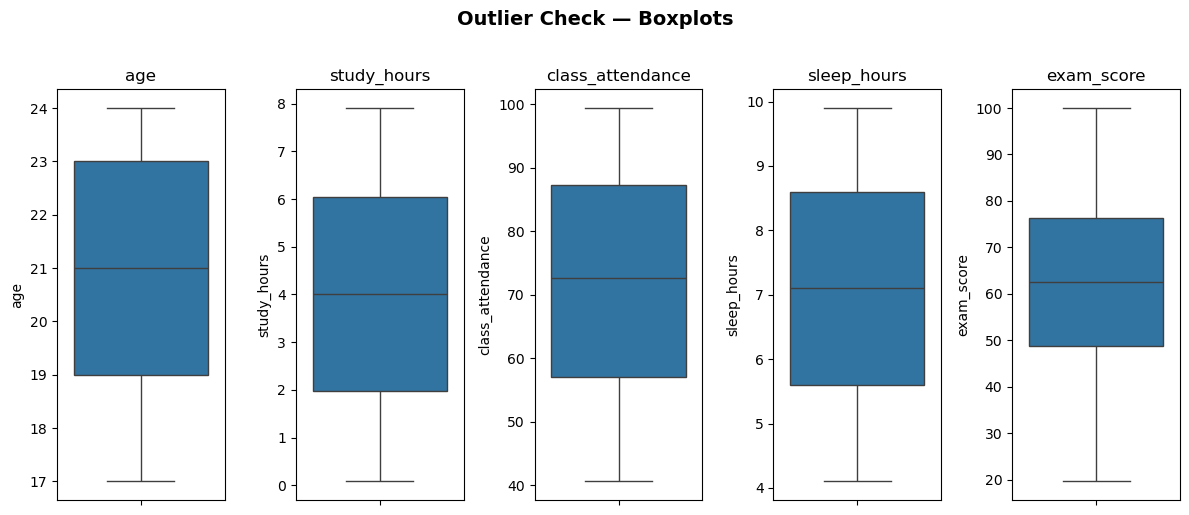

No outliers detected in any numeric feature!


In [7]:
#Outliers Check — Boxplot
numeric_cols = ['age', 'study_hours', 
                'class_attendance', 
                'sleep_hours', 'exam_score']

plt.figure(figsize=(12, 5))
for i, col in enumerate(numeric_cols):
    plt.subplot(1, 5, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.suptitle("Outlier Check — Boxplots", 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("No outliers detected in any numeric feature!")

### <b><u>Data Quality Summary<b><u>

| Check | Result |
|---|---|
| Missing Values |None found |
| Duplicate Rows | None found |
| Outliers | None detected |

**Conclusion:** Dataset is clean and ready for preprocessing.

## <b><u>Preprocessing<b><u>

In [8]:
#Remove the id column because it does not contribute to prediction.
df.drop(columns=["id"], inplace=True)

# Encode categorical variables
df = pd.get_dummies(data=df,
                    columns=['gender','course','internet_access',
                             'sleep_quality','study_method',
                             'facility_rating','exam_difficulty'],
                    dtype="int", drop_first=True)

# Split features and target
X = df.drop("exam_score", axis=1)
y = df["exam_score"]

print(f"Total features after encoding: {X.shape[1]}")
print(f"Total samples: {X.shape[0]}")

Total features after encoding: 23
Total samples: 630000


## <b><u>Baseline Model<b><u>

Before applying feature selection, we build a model using
ALL features to establish a benchmark R² score.

This will help us compare performance after feature selection.

In [9]:
# Train Test Split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Baseline Model 
model_baseline = LinearRegression()
model_baseline.fit(X_train, y_train)

# Training Scores
y_pred_train_base = model_baseline.predict(X_train)
r2_train_base = r2_score(y_train, y_pred_train_base)
rmse_train_base = np.sqrt(mean_squared_error(y_train, y_pred_train_base))

# Test Scores 
y_pred_test_base = model_baseline.predict(X_test)
r2_test_base = r2_score(y_test, y_pred_test_base)
rmse_test_base = np.sqrt(mean_squared_error(y_test, y_pred_test_base))

print("=" * 45)
print("      BASELINE MODEL (23 features)")
print("=" * 45)
print(f"  Training R²  : {r2_train_base:.4f}")
print(f"  Test R²      : {r2_test_base:.4f}")
print(f"  Training RMSE: {rmse_train_base:.4f}")
print(f"  Test RMSE    : {rmse_test_base:.4f}")
print("-" * 45)
diff_base = abs(r2_train_base - r2_test_base)
print(f"  R² Difference: {diff_base:.4f}")
if diff_base < 0.05:
    print("Good Fit — No overfitting/underfitting")
elif r2_train_base > r2_test_base + 0.05:
    print("Overfitting detected!")
else:
    print("Underfitting detected!")

      BASELINE MODEL (23 features)
  Training R²  : 0.7792
  Test R²      : 0.7780
  Training RMSE: 8.8964
  Test RMSE    : 8.8865
---------------------------------------------
  R² Difference: 0.0012
Good Fit — No overfitting/underfitting


## <b><u>RFECV — Recursive Feature Elimination with Cross Validation (Wrapper Method)<b><u>

Before applying individual feature selection methods, RFECV is used
to scientifically determine the optimal number of features.

**How it works:**
- Starts with all 23 features
- Removes one feature at a time
- Uses 5-Fold Cross Validation at each step to get honest R² score
- Identifies the number of features where R² is highest

**Why RFECV first ?**
Without this step, choosing k=5 or k=10 would be a guess.
RFECV gives a data-driven, scientifically proven answer.

**Advantages:**
- Automatically finds optimal feature count — no guessing needed
- Cross Validation gives honest, reliable results
- Prevents overfitting during feature selection

**Disadvantages:**
- Computationally expensive
- Slow on very large datasets

In [10]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

rfecv = RFECV(
    estimator=LinearRegression(),
    step=1,
    cv=cv,
    scoring='r2'
)
rfecv.fit(X_train, y_train)

print(f"Optimal number of features: {rfecv.n_features_}")
print(f"\nSelected features:")
print(list(X.columns[rfecv.support_]))

Optimal number of features: 17

Selected features:
['study_hours', 'class_attendance', 'sleep_hours', 'gender_male', 'gender_other', 'course_b.sc', 'course_b.tech', 'course_bba', 'course_diploma', 'sleep_quality_good', 'sleep_quality_poor', 'study_method_group study', 'study_method_mixed', 'study_method_online videos', 'study_method_self-study', 'facility_rating_low', 'facility_rating_medium']


### RFECV Plot

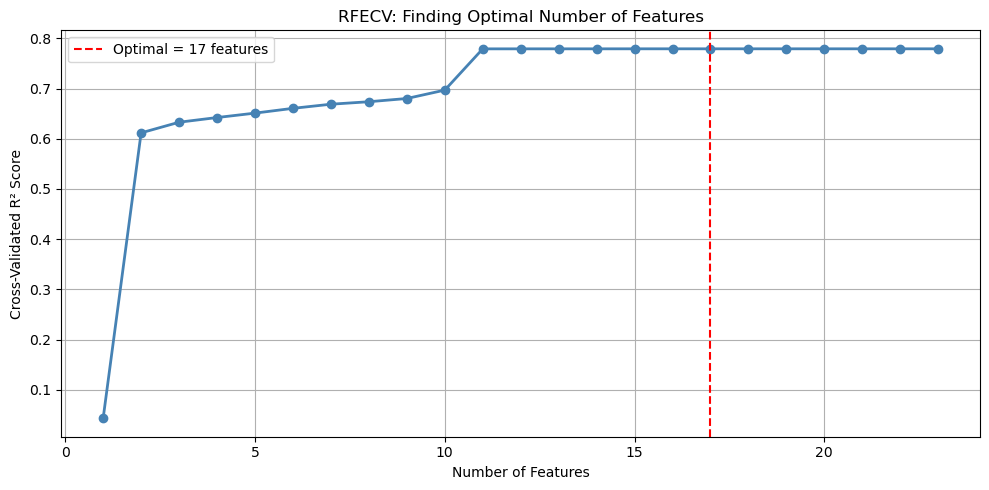

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(
    range(1, len(rfecv.cv_results_['mean_test_score']) + 1),
    rfecv.cv_results_['mean_test_score'],
    marker='o', color='steelblue', linewidth=2
)
plt.axvline(
    x=rfecv.n_features_, color='red', linestyle='--',
    label=f'Optimal = {rfecv.n_features_} features'
)
plt.xlabel("Number of Features")
plt.ylabel("Cross-Validated R² Score")
plt.title("RFECV: Finding Optimal Number of Features")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### RFECV Result

RFECV identified **17 features** as optimal.
Beyond 17, adding more features gives no improvement in R².
This means **6 of the original 23 features are completely redundant.**

All feature selection methods below will use **k = 17**.

### RFECV Deep Dive Analysis

RFECV selected 17 as optimal. Let's verify by checking
R² score at each feature count.

In [14]:
# RFECV Score at Each Feature Count
scores = rfecv.cv_results_['mean_test_score']

print("Features | R² Score")
print("-" * 25)
for i, score in enumerate(scores):
    marker = ""
    if i+1 == 11:
        marker = " ← practical optimum"
    if i+1 == rfecv.n_features_:
        marker = " ← RFECV selected (peak)"
    print(f"   {i+1:2d}    |  {score:.6f}{marker}")

# Key Stats
score_11 = scores[10]
score_17 = scores[16]
score_18 = scores[17]
diff_pct = ((score_17 - score_11) / score_11) * 100

print(f"\nBig Jump  (10→11): +{scores[10]-scores[9]:.4f}")
print(f"Gain      (11→17): +{score_17-score_11:.6f} ({diff_pct:.4f}%)")
print(f"After 17  (17→18): {score_18-score_17:.6f} ← dropped!")
print(f"\nRFECV selected {rfecv.n_features_} features (peak R²)")

Features | R² Score
-------------------------
    1    |  0.043297
    2    |  0.611720
    3    |  0.632904
    4    |  0.642250
    5    |  0.651042
    6    |  0.660566
    7    |  0.668778
    8    |  0.673721
    9    |  0.680156
   10    |  0.696864
   11    |  0.779039 ← practical optimum
   12    |  0.779066
   13    |  0.779074
   14    |  0.779086
   15    |  0.779126
   16    |  0.779134
   17    |  0.779139 ← RFECV selected (peak)
   18    |  0.779137
   19    |  0.779136
   20    |  0.779136
   21    |  0.779136
   22    |  0.779137
   23    |  0.779138

Big Jump  (10→11): +0.0822
Gain      (11→17): +0.000100 (0.0128%)
After 17  (17→18): -0.000002 ← dropped!

RFECV selected 17 features (peak R²)


### RFECV Observation

| Zone | Features | Behavior |
|---|---|---|
| Learning | 1 → 10 | R² grows rapidly |
| Saturation | 11 → 17 | Only 0.0128% gain |
| Noise | 18 → 23 | R² drops |

**RFECV selected 17 features** — mathematical peak (R² = 0.779139)

**Note:**   
R² stabilizes at 11 features (R² = 0.779039).  
The gain from 11 → 17 is only 0.0128% — negligible.  
For production, 11 features would be sufficient.  

We proceed with **17 features** for complete analysis as R² drops after this point.

# <u><b>Method 1: Correlation (Filter Method)</u></b>
Correlation measures the relationship between each feature and the target variable.

**Advantages :**    
-Very simple and easy to interpret    
-Computationally fast    
-Useful for identifying strongly related variables   

**Disadvantages :**   
-only detects linear relationships    
-ignores interaction between features

**When to use:** Quick initial scan to find strongly related variables.

**Why it is better than others:**   
Correlation is often used as the first step in feature selection because it quickly identifies strongly related features before applying more complex methods.

exam_score                    1.000000
study_hours                   0.762267
class_attendance              0.360954
sleep_quality_good            0.203258
sleep_hours                   0.167410
study_method_mixed            0.067598
facility_rating_medium        0.019808
course_bba                    0.014164
age                           0.010472
gender_other                  0.010302
exam_difficulty_moderate      0.005950
exam_difficulty_hard          0.003777
course_bca                    0.001703
internet_access_yes           0.000447
course_b.tech                 0.000353
course_diploma               -0.001587
course_b.sc                  -0.005178
course_ba                    -0.010823
gender_male                  -0.012403
study_method_group study     -0.051422
study_method_online videos   -0.071656
study_method_self-study      -0.130269
facility_rating_low          -0.171604
sleep_quality_poor           -0.208717
Name: exam_score, dtype: float64


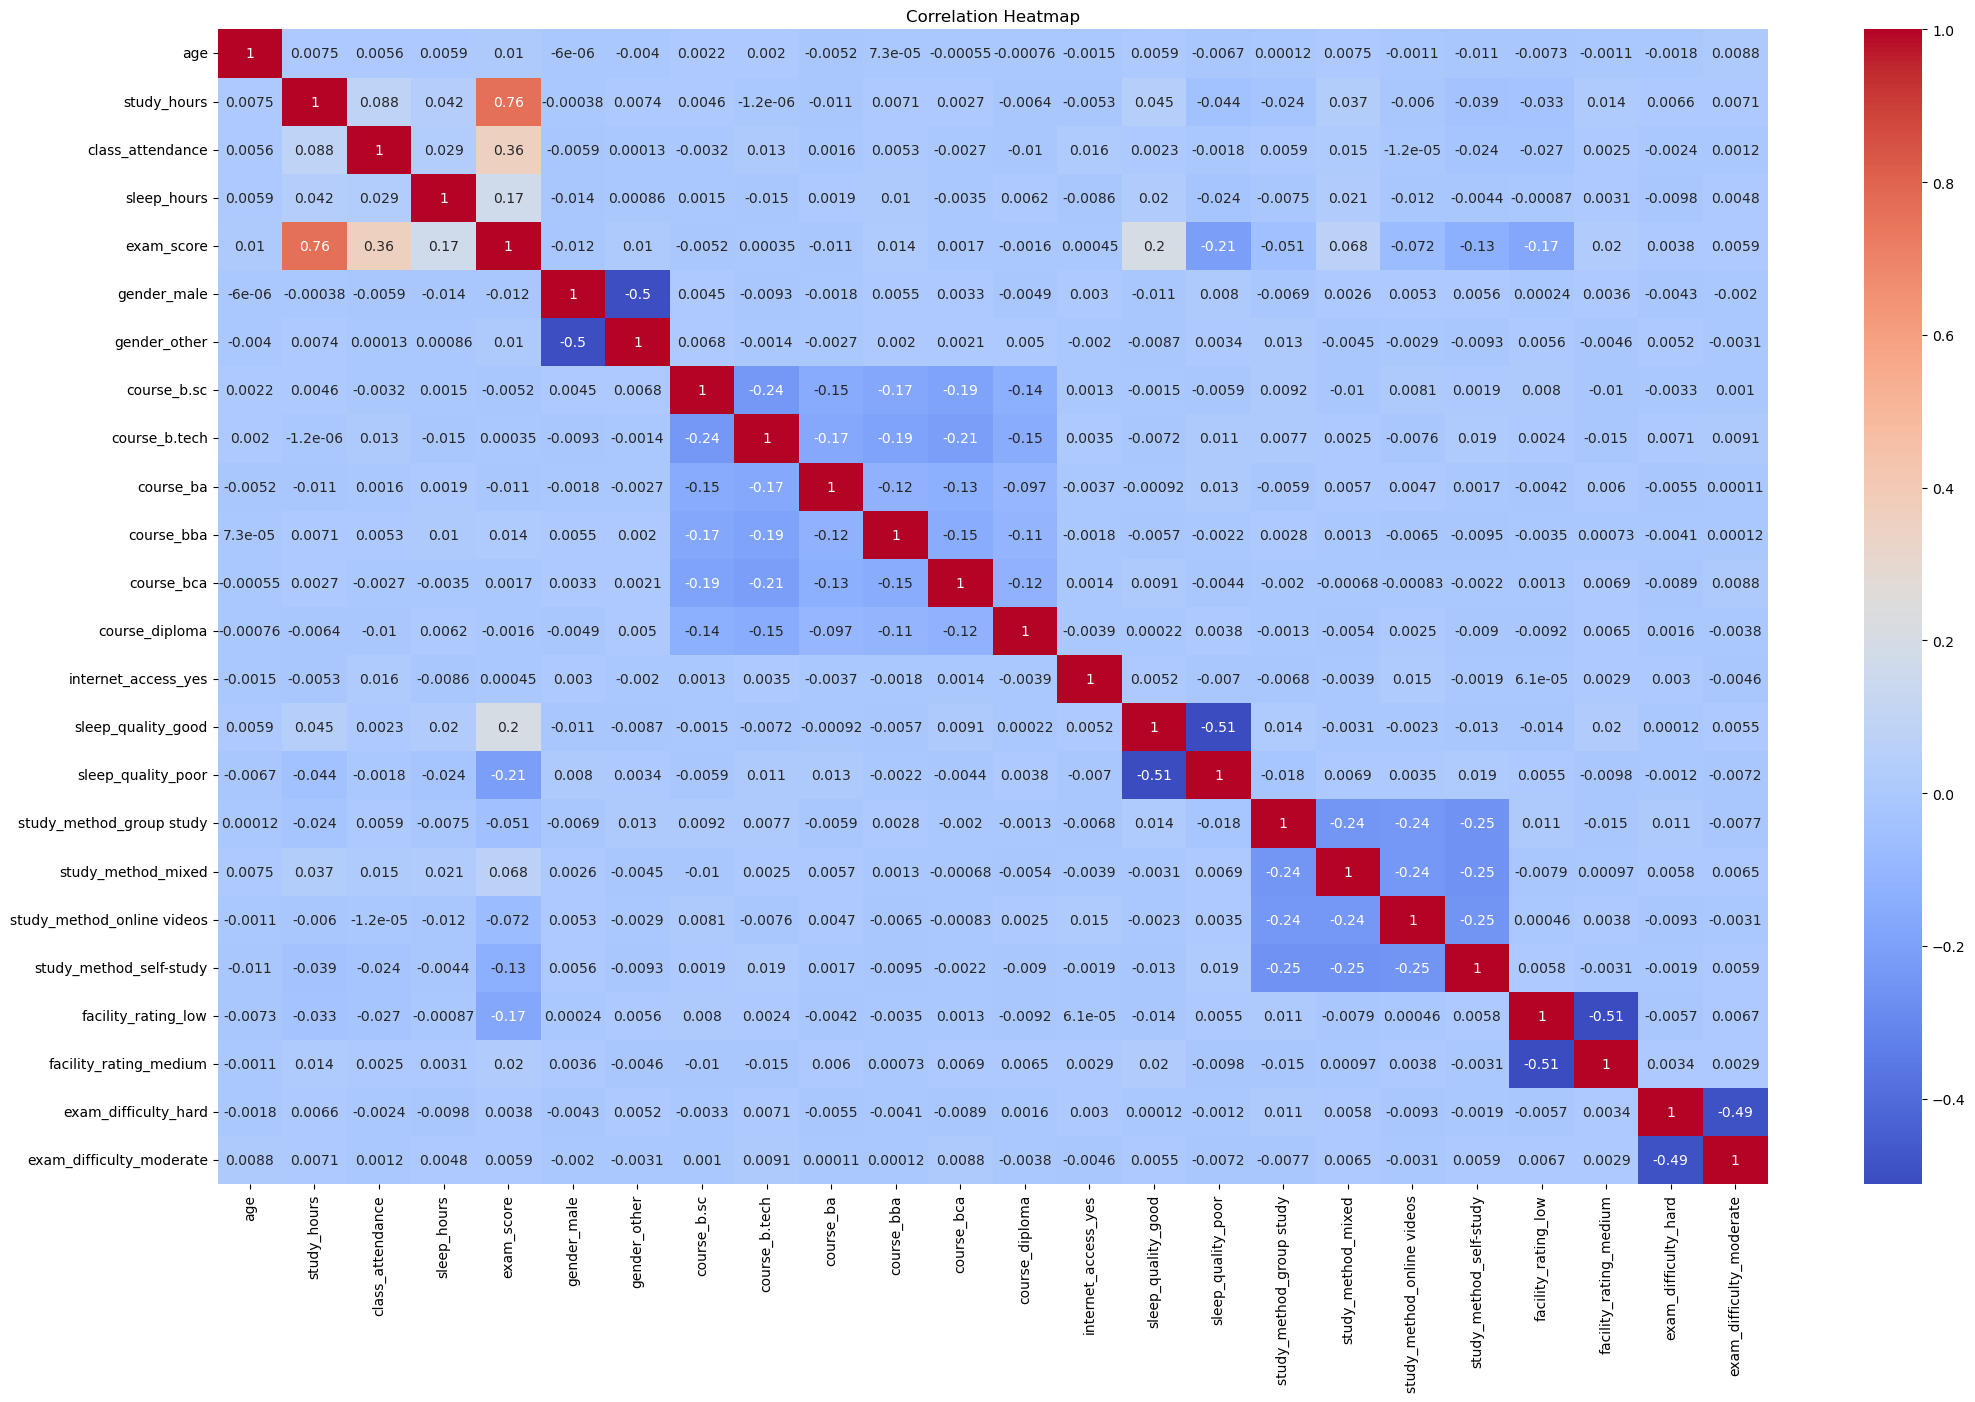

In [81]:
corr = df.corr()
print(corr["exam_score"].sort_values(ascending=False))

plt.figure(figsize=(25,15))
sns.heatmap(df.corr(), cmap="coolwarm", annot=True)
plt.title("Correlation Heatmap")
plt.show()

#### Important Features from above result:
Below features have the strongest relationship with exam_score

study_hours  
class_attendance     
sleep_quality_good   
sleep_hours   
sleep_quality_poor    


--Correlation analysis shows that **study hours** have the strongest relationship with exam scores (0.762), 
indicating that students who study more tend to achieve higher marks.

--**Class attendance** also shows a moderate positive correlation (0.36), 
suggesting that attending lectures improves academic performance.

--**Sleep quality** and **sleep hours** also influence exam scores, while variables such as course type, gender, 
and internet access show very weak correlations and are therefore less important for predicting exam results.

# <u><b>Method 2: Variance Threshold (Filter Method)<u><b>
This method removes features with very low variance because they contain little information.

**Advantages :**    
-Extremely fast and simple   
-Reduces dataset size quickly   
-Does not require target variable      

**Disadvantages :**   
-Ignores relationship with the target variable   
-Important low-variance features may be removed   


**Why it is better than others:**   
Variance Threshold is useful as a preprocessing step to remove constant or nearly constant features before applying more complex methods.

In [82]:
selector = VarianceThreshold(threshold=0.01)

X_var = selector.fit_transform(X)

selected_features = X.columns[selector.get_support()]

print(selected_features)

Index(['age', 'study_hours', 'class_attendance', 'sleep_hours', 'gender_male',
       'gender_other', 'course_b.sc', 'course_b.tech', 'course_ba',
       'course_bba', 'course_bca', 'course_diploma', 'internet_access_yes',
       'sleep_quality_good', 'sleep_quality_poor', 'study_method_group study',
       'study_method_mixed', 'study_method_online videos',
       'study_method_self-study', 'facility_rating_low',
       'facility_rating_medium', 'exam_difficulty_hard',
       'exam_difficulty_moderate'],
      dtype='object')


#### Selected Features from above result :
The model kept below features because they have sufficient variability:

age , 
study_hours , 
class_attendance , 
sleep_hours , 
gender_male , gender_other
course_b.sc , 
course_b.tech , 
course_ba , 
course_bba , 
course_bca , 
course_diploma ,
internet_access_yes , sleep_quality_good , 
sleep_quality_poor , 
study_method_group study , 
study_method_mixed ,
study_method _online videos ,
study_method_self-study , 
facility_rating_low , facility_rating_medium , exam_difficulty_hard , exam_difficulty_moderate

The Variance Threshold method was applied with a threshold value of 0.01 to remove features with very low variance.   
The results show that most variables in the dataset have sufficient variability and were therefore retained. 
This indicates that the dataset contains diverse feature values that may contribute to predicting exam performance.   

# <u><b>Method 3: Chi-Square (Filter Method)<u><b>
Chi-Square measures the statistical dependency between categorical
features and the target variable.


**Advantages :**    
-Very effective for categorical features   
-Simple statistical method   
-Computationally efficient    

**Disadvantages :**   
-Works only with non-negative data   
-Requires categorical variables   
-Cannot handle continuous features directly   


**Why it is better than others:**   
Chi-square is particularly useful in classification problems with categorical data, such as text classification or survey datasets.

In [83]:
y_cat = pd.cut(y, bins=3, labels=[0,1,2]) #Convert Target into Classes

In [84]:
#Scale Features (Chi-Square requires non-negative values)

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [85]:
selector = SelectKBest(score_func=chi2, k=17)

X_new = selector.fit_transform(X_scaled, y_cat)

print(X.columns[selector.get_support()])

Index(['study_hours', 'class_attendance', 'sleep_hours', 'gender_male',
       'gender_other', 'course_b.sc', 'course_ba', 'course_bba',
       'sleep_quality_good', 'sleep_quality_poor', 'study_method_group study',
       'study_method_mixed', 'study_method_online videos',
       'study_method_self-study', 'facility_rating_low',
       'facility_rating_medium', 'exam_difficulty_hard'],
      dtype='object')


#### Important Features from above result:
Below variables show the strongest statistical relationship with the target variable according to the Chi-Square test.

'study_hours', 'class_attendance', 'sleep_hours', 'gender_male',
       'gender_other', 'course_b.sc', 'course_ba', 'course_bba',
       'sleep_quality_good', 'sleep_quality_poor', 'study_method_group study',
       'study_method_mixed', 'study_method_online videos',
       'study_method_self-study', 'facility_rating_low',
       'facility_rating_medium', 'exam_difficulty_hard'


# <u><b>Method 4: Mutual Information (Filter Method)<u><b>
Mutual Information measures how much information one variable provides about another variable.

**Advantages :**    
-Detects non-linear relationships   
-Works with both continuous and categorical variables   
-More flexible than correlation     

**Disadvantages :**   
-Computationally slower than correlation   
-Harder to interpret   
-Requires more data to estimate accurately  


**Why it is better than others:**   
Mutual Information is better than correlation when relationships are nonlinear, which is common in real-world datasets.

In [86]:
mi = mutual_info_regression(X, y)

mi_scores = pd.Series(mi, index=X.columns)

print(mi_scores.sort_values(ascending=False))

study_hours                   0.910979
class_attendance              0.302607
sleep_hours                   0.073254
sleep_quality_poor            0.028254
sleep_quality_good            0.024809
facility_rating_low           0.023208
age                           0.012514
study_method_self-study       0.011654
study_method_online videos    0.007868
study_method_mixed            0.006983
facility_rating_medium        0.006724
exam_difficulty_moderate      0.005377
study_method_group study      0.004606
course_b.sc                   0.004363
course_b.tech                 0.004199
internet_access_yes           0.003306
course_diploma                0.003171
gender_male                   0.002763
course_bca                    0.002345
course_ba                     0.002155
course_bba                    0.002007
gender_other                  0.001993
exam_difficulty_hard          0.001634
dtype: float64


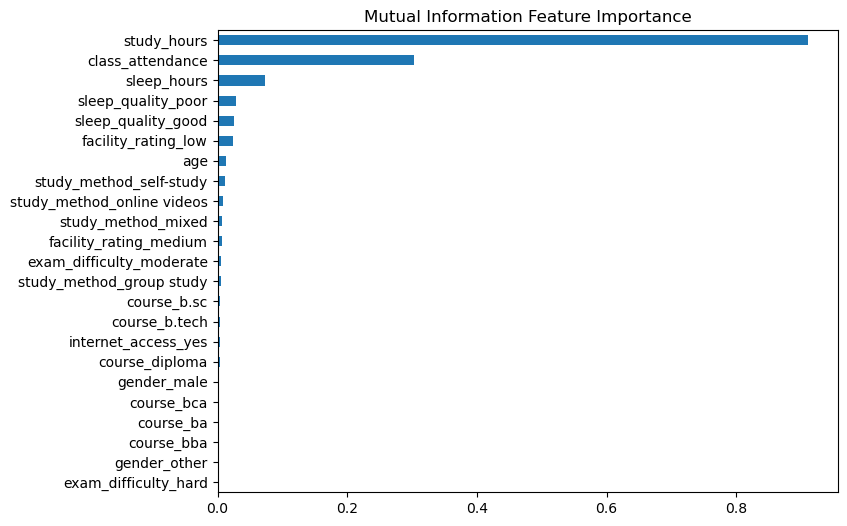

In [87]:
mi_scores.sort_values().plot.barh(figsize=(8,6))
plt.title("Mutual Information Feature Importance")
plt.show()

#### Important Features from above result:

Below features provide the highest information gain about the target variable.

study_hours   
class_attendance   
sleep_hours    
sleep_quality_good   
sleep_quality_poor    

The results highlight that study hours and class attendance provide the most predictive information, while sleep-related variables also contribute moderately.

## <u><b>Method 5: Variance Inflation Factor (Filter Method) – Multicollinearity Check<u><b>
Detects multicollinearity — features that are highly
correlated with each other.

**Advantages :**    
-Detects redundant features    
-Improves model stability      
-Important for regression models         

**Disadvantages :**   
-Does not consider relationship with the target variable   
-Only detects linear multicollinearity   
-Can be computationally expensive for large datasets  


**Why it is better than others:**   
VIF is better when the goal is to remove highly correlated predictors, which can negatively affect regression models.

In [88]:
vif = pd.DataFrame()                  #If VIF > 5 or 10 → feature may cause multicollinearity.

vif["Feature"] = X.columns

vif["VIF"] = [variance_inflation_factor(X.values, i)
              for i in range(X.shape[1])]

print(vif)

                       Feature        VIF
0                          age  36.664854
1                  study_hours   3.901427
2             class_attendance  16.408995
3                  sleep_hours  15.680496
4                  gender_male   1.989132
5                 gender_other   1.992297
6                  course_b.sc   1.971145
7                course_b.tech   2.144655
8                    course_ba   1.538019
9                   course_bba   1.658057
10                  course_bca   1.770690
11              course_diploma   1.432354
12         internet_access_yes  11.494921
13          sleep_quality_good   2.032595
14          sleep_quality_poor   2.028335
15    study_method_group study   1.905954
16          study_method_mixed   1.910453
17  study_method_online videos   1.889848
18     study_method_self-study   1.962719
19         facility_rating_low   2.017230
20      facility_rating_medium   2.028123
21        exam_difficulty_hard   1.551226
22    exam_difficulty_moderate   2

### Important Features from Above Result
Below features with acceptable VIF values include:   
These variables have low multicollinearity and can be used safely in predictive models.

study_hours ,
gender_male ,
gender_other ,
course_b.sc ,
course_b.tech ,
course_ba ,
course_bba ,
course_bca ,
course_diploma ,
sleep_quality_good ,
sleep_quality_poor ,
study_method_group study ,
study_method_mixed, 
study_method_online videos ,
study_method_self-study ,
facility_rating_low ,
facility_rating_medium ,
exam_difficulty_moderate 

Variance Inflation Factor analysis was performed to detect multicollinearity among the features.    
The results show that most variables have acceptable VIF values between 1 and 5, indicating low multicollinearity.  

However, features such as age, class_attendance, sleep_hours, and internet_access_yes show high VIF values,
suggesting strong correlation with other variables. Removing or modifying these variables may help improve model stability.

## <u><b>Method 6: RFE — Recursive Feature Elimination (Wrapper Method)<u><b>
RFE repeatedly removes the least important features and retrains the model.

**Advantages :**    
-Produces highly accurate feature subsets    
-Works with many machine learning algorithms   
-Automatically ranks features      

**Disadvantages :**   
-Computationally expensive   
-Slow for large datasets   
-Requires model training multiple times   


**Why it is better than others:**   
RFE is better when high accuracy is required, because it evaluates feature importance directly using a machine learning model.

**Difference from RFECV:**    
RFE requires you to specify n_features manually.
RFECV (used above) automatically found the optimal number = 17.
So here we use n_features_to_select = 17.

In [89]:
model = LinearRegression()

rfe = RFE(model, n_features_to_select=17)

rfe.fit(X, y)

print(X.columns[rfe.support_])

Index(['study_hours', 'class_attendance', 'sleep_hours', 'gender_male',
       'gender_other', 'course_b.sc', 'course_b.tech', 'course_bba',
       'course_diploma', 'sleep_quality_good', 'sleep_quality_poor',
       'study_method_group study', 'study_method_mixed',
       'study_method_online videos', 'study_method_self-study',
       'facility_rating_low', 'facility_rating_medium'],
      dtype='object')


#### Important Features from above result:

Below features were selected by recursively removing the least important variables until the optimal subset was obtained.

study_hours, class_attendance, sleep_hours, gender_male, gender_other, course_b.sc, course_b.tech, course_bba, course_diploma, sleep_quality_good, sleep_quality_poor,study_method_group study, study_method_mixed, study_method_online videos, study_method_self-study, facility_rating_low, facility_rating_medium
 
This method is powerful because it considers the performance of the model while selecting features.

# <u><b>Method 7: Sequential Feature Selection (Wrapper Method)<u><b>
Sequential Feature Selection adds or removes features step by step.


**Advantages :**    
-Finds optimal feature combinations
-Works with many models
-Flexible feature selection strategy

**Disadvantages :**   
-Very slow for large datasets
-Computationally expensive
-Risk of overfitting


**Why it is better than others:**   
Sequential feature selection is useful when feature interactions matter, since it evaluates features in combination rather than individually.

In [90]:
model = LinearRegression()

sfs = SequentialFeatureSelector(model,
                                n_features_to_select=17)

sfs.fit(X, y)
print(X.columns[sfs.get_support()])

Index(['study_hours', 'class_attendance', 'sleep_hours', 'gender_male',
       'gender_other', 'course_b.sc', 'course_b.tech', 'course_bba',
       'course_diploma', 'sleep_quality_good', 'sleep_quality_poor',
       'study_method_group study', 'study_method_mixed',
       'study_method_online videos', 'study_method_self-study',
       'facility_rating_low', 'facility_rating_medium'],
      dtype='object')


#### Important Features from Above Result
Below variables contribute the most to improving the prediction accuracy of the model.

study_hours, class_attendance, sleep_hours, gender_male, gender_other, course_b.sc, course_b.tech, course_bba, course_diploma, sleep_quality_good, sleep_quality_poor,study_method_group study, study_method_mixed, study_method_online videos, study_method_self-study, facility_rating_low, facility_rating_medium   


# <u><b>Method 8: Lasso Feature Selection (Embedded Method)<u><b>
Lasso automatically removes less important features by forcing coefficients toward zero.

**Advantages :**    
-Performs automatic feature selection    
-Reduces overfitting     
-Works well with high-dimensional datasets   

**Disadvantages :**   
-May remove useful correlated features   
-Sensitive to regularization parameter
-Works best with linear models  


**Why it is better than others:**   
Lasso is widely used because it selects features automatically while training the model, making it efficient and practical.

In [91]:
lasso = Lasso(alpha=0.1)

lasso.fit(X, y)

importance = pd.Series(np.abs(lasso.coef_), index=X.columns)

print(importance.sort_values(ascending=False))

study_method_self-study       6.724033
facility_rating_low           6.368327
study_method_online videos    5.858930
study_hours                   5.681120
study_method_group study      4.795436
sleep_quality_poor            4.410416
sleep_quality_good            3.934371
facility_rating_medium        2.644954
study_method_mixed            2.022485
sleep_hours                   1.293232
class_attendance              0.312836
course_b.sc                   0.000000
gender_other                  0.000000
gender_male                   0.000000
age                           0.000000
course_diploma                0.000000
internet_access_yes           0.000000
course_bba                    0.000000
course_bca                    0.000000
course_ba                     0.000000
course_b.tech                 0.000000
exam_difficulty_hard          0.000000
exam_difficulty_moderate      0.000000
dtype: float64


#### Important Features from above result:

Below features have the largest coefficients after applying Lasso regularization.

study_method_self-study   
facility_rating_low   
study_method_online videos  
study_hours   
study_method_group study   
sleep_quality_poor   

The results highlight that study methods and study hours play an important role in determining exam performance. 

## <u><b>METHOD 9 : Random Forest Feature Importance (Embedded)<u><b>
Measures feature importance based on how much each feature
reduces impurity across all decision tree splits.

**Advantages :**    
-Handles nonlinear relationships   
-Works well with large datasets  
-Captures feature interactions     

**Disadvantages :**   
-Harder to interpret
-Can bias toward features with more categories
-Computationally heavier than filter methods

**Why it is better than others:**   
Random Forest importance is powerful because it captures complex nonlinear relationships and feature interactions.

In [92]:
rf = RandomForestRegressor()

rf.fit(X, y)

importance = pd.Series(rf.feature_importances_,
                       index=X.columns)

importance.sort_values()

internet_access_yes           0.003507
course_diploma                0.003746
course_ba                     0.004112
exam_difficulty_hard          0.004469
course_bba                    0.004557
course_bca                    0.004864
course_b.sc                   0.005183
course_b.tech                 0.005415
study_method_mixed            0.005682
gender_male                   0.005875
gender_other                  0.005914
exam_difficulty_moderate      0.006202
facility_rating_medium        0.006937
study_method_group study      0.008353
study_method_online videos    0.008862
study_method_self-study       0.009956
sleep_quality_good            0.014417
facility_rating_low           0.019191
sleep_quality_poor            0.024201
age                           0.024349
sleep_hours                   0.054307
class_attendance              0.139994
study_hours                   0.629908
dtype: float64

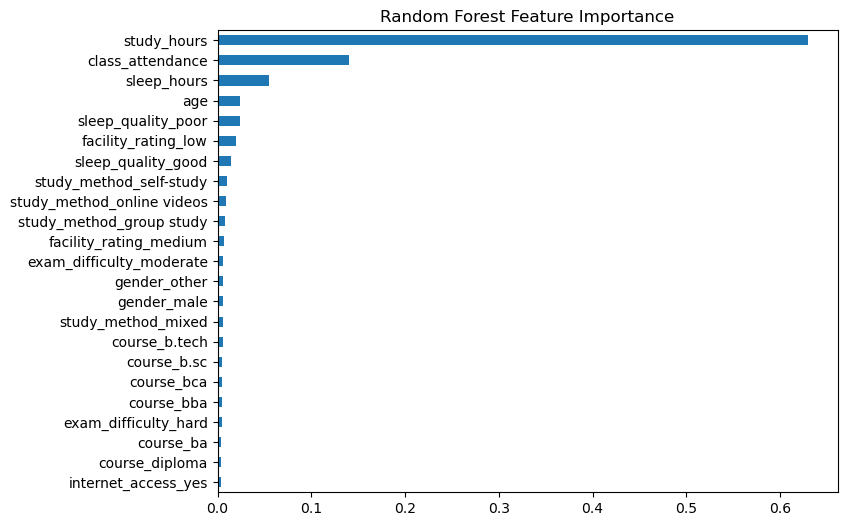

In [93]:
rf = RandomForestRegressor()

rf.fit(X, y)

importance = pd.Series(rf.feature_importances_,
                       index=X.columns)

importance.sort_values().plot.barh(figsize=(8,6))

plt.title("Random Forest Feature Importance")
plt.show()

#### Important Features from above result:

Below variables received the highest importance scores from the Random Forest model.
    
study hours   
class_attendance   
sleep hours   

Random Forest feature importance shows that study_hours is the most influential factor affecting exam scores, 
followed by class attendance and sleep hours.     
Other variables such as study methods, facility rating, gender, and course type have very low importance in predicting performance. 
This indicates that students’ study habits and attendance play the most significant role in exam outcomes.

## <u><b>**Comparison of Feature Selection Methods**<u><b>

Different feature selection methods were applied to identify the most important variables affecting exam_score.   
Each method selects features using a different approach.

| Method                                  | Selected Important Features                                                                                                         |
| --------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------- |
| **Correlation Method**                  | study_hours, class_attendance, sleep_quality_good, sleep_hours                                                                      |
| **Variance Threshold**                  | Most features retained because variance was above the threshold                                                                     |
| **Chi-Square Method**                   |study_hours, class_attendance, sleep_hours, gender_male, gender_other, course_b.sc, course_ba, course_bba,  sleep_quality_good, sleep_quality_poor,study_method_group study, study_method_mixed, study_method_online videos, study_method_self-study, facility_rating_low, facility_rating_medium, exam_difficulty_hard|
| **Mutual Information**                  | study_hours, class_attendance, sleep_hours, sleep_quality_good, sleep_quality_poor                                                  |
| **VIF Analysis**                        | Identified multicollinearity; high VIF for age, class_attendance, sleep_hours                                                       |
| **Recursive Feature Elimination (RFE)** | study_hours, class_attendance, sleep_hours, gender_male, gender_other, course_b.sc, course_b.tech, course_bba, course_diploma, sleep_quality_good, sleep_quality_poor,study_method_group study, study_method_mixed, study_method_online videos, study_method_self-study, facility_rating_low, facility_rating_medium |
| **Sequential Feature Selection (SFS)**  | study_hours, class_attendance, sleep_hours, gender_male, gender_other, course_b.sc, course_b.tech, course_bba, course_diploma, sleep_quality_good, sleep_quality_poor,study_method_group study, study_method_mixed, study_method_online videos, study_method_self-study, facility_rating_low, facility_rating_medium |
| **Lasso Feature Selection**             | study_method_self-study, facility_rating_low, study_method_online videos, study_hours, study_method_group study, sleep_quality_poor |
| **Random Forest Feature Importance**    | study_hours, class_attendance, sleep_hours, sleep_quality_poor, facility_rating_low                                                 |


## <u><b>**Final Selected Features**<u><b>
After comparing all feature selection methods, features selected by 5 or more methods :

**study_hours**   
**class_attendance**  
**sleep_hours**  
**sleep_quality_good**    
**sleep_quality_poor**   
**facility_rating_low**    

These features appear in multiple feature selection techniques, indicating they have strong predictive power for exam performance.

### <b><u>FINAL MODEL<b><u>

In [94]:
#Final Model with RFECV selected 17 features 
X_train_opt = X_train.loc[:, rfecv.support_]
X_test_opt  = X_test.loc[:, rfecv.support_]

model_final = LinearRegression()
model_final.fit(X_train_opt, y_train)

#Training Scores
y_pred_train_final = model_final.predict(X_train_opt)
r2_train_final  = r2_score(y_train, y_pred_train_final)
rmse_train_final = np.sqrt(mean_squared_error(y_train, y_pred_train_final))

#Test Scores 
y_pred_test_final = model_final.predict(X_test_opt)
r2_test_final  = r2_score(y_test, y_pred_test_final)
rmse_test_final = np.sqrt(mean_squared_error(y_test, y_pred_test_final))

print("=" * 45)
print("     FINAL MODEL (17 features)")
print("=" * 45)
print(f"  Training R²  : {r2_train_final:.4f}")
print(f"  Test R²      : {r2_test_final:.4f}")
print(f"  Training RMSE: {rmse_train_final:.4f}")
print(f"  Test RMSE    : {rmse_test_final:.4f}")
print("-" * 45)
diff_final = abs(r2_train_final - r2_test_final)
print(f"  R² Difference: {diff_final:.4f}")
if diff_final < 0.05:
    print("Good Fit — No overfitting/underfitting")
elif r2_train_final > r2_test_final + 0.05:
    print("Overfitting detected!")
else:
    print("Underfitting detected!")

     FINAL MODEL (17 features)
  Training R²  : 0.7792
  Test R²      : 0.7780
  Training RMSE: 8.8965
  Test RMSE    : 8.8866
---------------------------------------------
  R² Difference: 0.0012
Good Fit — No overfitting/underfitting


### <b><u>BEFORE vs AFTER COMPARISON<b><u>

                 Model  Features Used  Train R²  Test R²  Train RMSE  Test RMSE Overfit?
Baseline (23 features)             23    0.7792    0.778      8.8964     8.8865      No 
   Final (17 features)             17    0.7792    0.778      8.8965     8.8866      No 


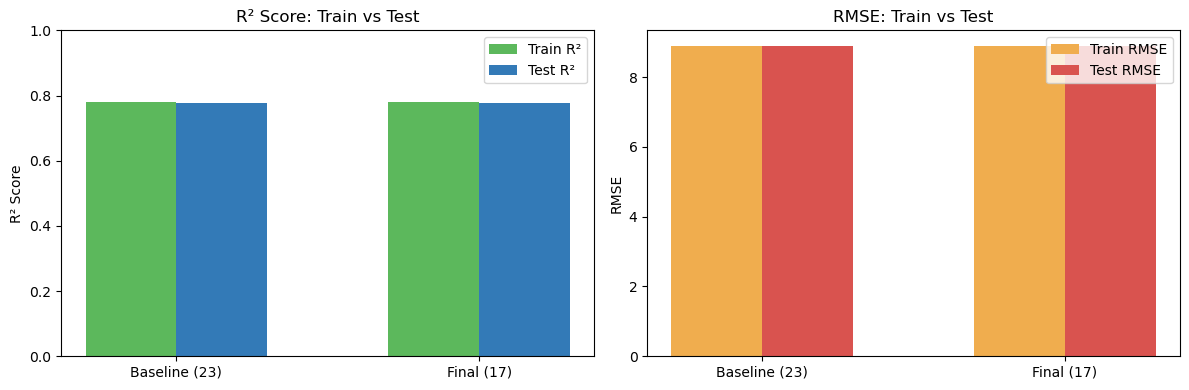

In [95]:
# Comparison Table
comparison = pd.DataFrame({
    'Model': ['Baseline (23 features)', 'Final (17 features)'],
    'Features Used': [23, 17],
    'Train R²':   [round(r2_train_base, 4),  round(r2_train_final, 4)],
    'Test R²':    [round(r2_test_base, 4),   round(r2_test_final, 4)],
    'Train RMSE': [round(rmse_train_base, 4), round(rmse_train_final, 4)],
    'Test RMSE':  [round(rmse_test_base, 4),  round(rmse_test_final, 4)],
    'Overfit?': [
        'No ' if abs(r2_train_base - r2_test_base) < 0.05 else 'Yes ',
        'No ' if abs(r2_train_final - r2_test_final) < 0.05 else 'Yes '
    ]
})

print(comparison.to_string(index=False))

# Charts
x = np.arange(2)
width = 0.3
labels = ['Baseline (23)', 'Final (17)']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# R² comparison
axes[0].bar(x - width/2, [r2_train_base, r2_train_final],
            width, label='Train R²', color='#5cb85c')
axes[0].bar(x + width/2, [r2_test_base, r2_test_final],
            width, label='Test R²', color='#337ab7')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0, 1)
axes[0].set_title('R² Score: Train vs Test')
axes[0].legend()

# RMSE comparison
axes[1].bar(x - width/2, [rmse_train_base, rmse_train_final],
            width, label='Train RMSE', color='#f0ad4e')
axes[1].bar(x + width/2, [rmse_test_base, rmse_test_final],
            width, label='Test RMSE', color='#d9534f')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_ylabel('RMSE')
axes[1].set_title('RMSE: Train vs Test')
axes[1].legend()

plt.tight_layout()
plt.show()

# <b><u>**Conclusion**<b><u>

### **What We Did**:
1. Built a baseline model with all 23 features → established R² benchmark
2. Used RFECV to scientifically find optimal features → 17 features identified
3. Applied 9 feature selection methods with k=17 to understand feature importance
4. Built final model with 17 features → compared performance

### **Key Findings**:

##### **RFECV proved that 6 out of 23 features were completely redundant.**
Removing them caused zero loss in model performance.

##### **study_hours was the most consistent feature** 
selected by all 9 methods, confirming it is the strongest predictor of exam performance.

##### **Best Feature Selection Method: RFECV**
- Automatically determined optimal feature count (17)
- Cross-validated results — honest and reliable
- Same R² achieved with 26% fewer features
- No overfitting detected

##### **Production Note:**   
R² stabilizes at 11 features (0.0128% difference from 17).   
For real-world deployment, 11 features would reduce data collection cost while maintaining the same predictive performance.

### **Final Result:**

| | Before | After |
|---|---|---|
| Features | 23 | 17 |
| Test R² | 0.778 | 0.778 |
| Overfit? | No | No |
| Model Complexity | High | Low |

> Feature selection reduced features from 23 to 17 while maintaining
> the same R² = 0.778. The model is now simpler, faster, and more
> generalizable — proving that 6 features were completely unnecessary.